In [2]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    # Python & NumPy
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Random seed set to {seed} for reproducibility.")

set_seed(42)

Random seed set to 42 for reproducibility.


In [4]:
import os
from pathlib import Path
from collections import Counter

def analyze_dataset_structure(root_dir):
    root = Path(root_dir)
    if not root.exists():
        print(f"Directory not found: {root_dir}")
        return

    file_extensions = Counter()
    subdirectories = [d.name for d in root.iterdir() if d.is_dir()]
    total_files = 0
    sample_files = []

    for filepath in root.rglob('*'):
        if filepath.is_file():
            file_extensions[filepath.suffix.lower()] += 1
            total_files += 1
            if len(sample_files) < 5:
                sample_files.append(str(filepath.relative_to(root)))

    print(f"--- Dataset Analysis: {root.name} ---")
    print(f"Total Files: {total_files}")
    print(f"Total Subdirectories: {len(subdirectories)}")
    
    if subdirectories:
        print(f"Sample Subdirectories: {subdirectories[:10]}")

    print("\nFile Breakdown by Extension:")
    for ext, count in file_extensions.items():
        print(f"  {ext if ext else 'No Extension'}: {count}")

    print("\nSample File Paths:")
    for file in sample_files:
        print(f"  {file}")

if __name__ == "__main__":
    dataset_path = "/kaggle/input/datasets/ateebnoone/fruits-dataset-for-fruit-disease-classification" 
    analyze_dataset_structure(dataset_path)

--- Dataset Analysis: fruits-dataset-for-fruit-disease-classification ---
Total Files: 6537
Total Subdirectories: 4
Sample Subdirectories: ['POMEGRANATE', 'APPLE', 'GUAVA', 'MANGO']

File Breakdown by Extension:
  .jpg: 5837
  .png: 700

Sample File Paths:
  POMEGRANATE/Anthracnose_Pomegranate/IMG_20230813_151636.jpg
  POMEGRANATE/Anthracnose_Pomegranate/IMG_20230903_131050.jpg
  POMEGRANATE/Anthracnose_Pomegranate/IMG_20230903_130703_1.jpg
  POMEGRANATE/Anthracnose_Pomegranate/IMG_20230903_142451.jpg
  POMEGRANATE/Anthracnose_Pomegranate/IMG_20230903_150143.jpg



=== FRUIT DISEASE DATASET (17 Classes) ===
Path: /kaggle/input/datasets/ateebnoone/fruits-dataset-for-fruit-disease-classification
  • Anthracnose_Pomegranate        | 1166 images
  • Cercospora_Pomegranate         | 631 images
  • Healthy_Pomegranate            | 1450 images
  • Alternaria_Pomegranate         | 886 images
  • Bacterial_Blight_Pomegranate   | 966 images
  • Blotch_Apple                   | 100 images
  • Healthy_Apple                  | 100 images
  • Scab_Apple                     | 100 images
  • Rot_Apple                      | 100 images
  • Healthy_Guava                  | 100 images
  • Fruitfly_Guava                 | 100 images
  • Anthracnose_Guava              | 100 images
  • Stem and Rot (Lasiodiplodia)_Mango | 157 images
  • Anthracnose_Mango              | 79 images
  • Alternaria_Mango               | 115 images
  • Healthy_Mango                  | 205 images
  • Black Mould Rot (Aspergillus)_Mango | 182 images
TOTAL: 6537 images


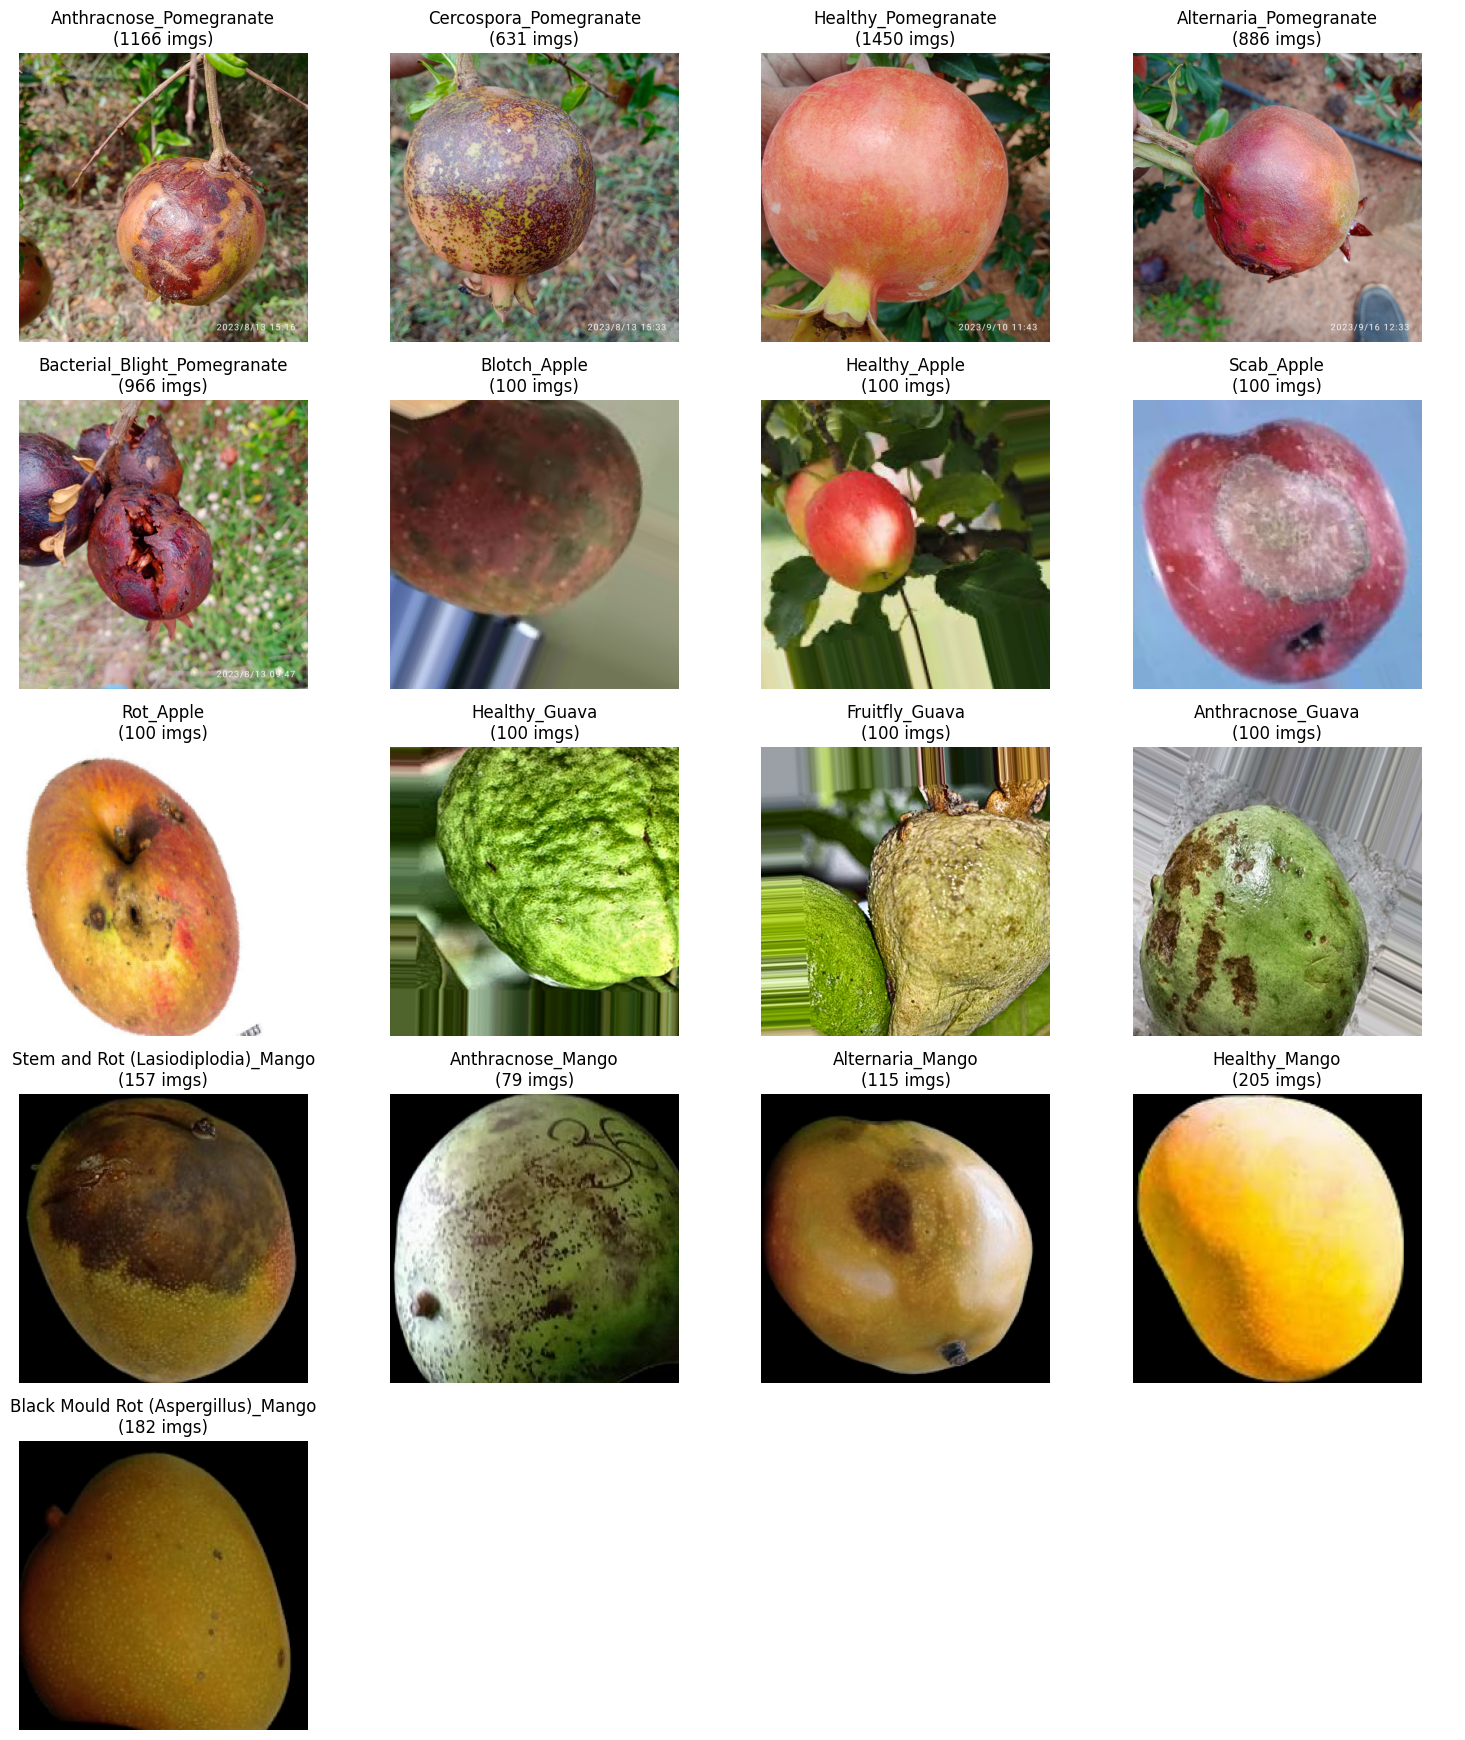

In [6]:
import os
import glob
import cv2
import math
import matplotlib.pyplot as plt

DATASET_DIR = '/kaggle/input/datasets/ateebnoone/fruits-dataset-for-fruit-disease-classification'

def inspect_and_plot(data_path, dataset_name):
    if not os.path.exists(data_path):
        print(f"Error: Path not found: {data_path}")
        return

    disease_paths = glob.glob(os.path.join(data_path, '*', '*'))
    disease_paths = [p for p in disease_paths if os.path.isdir(p)]
    
    classes = sorted([os.path.basename(p) for p in disease_paths])
    
    print(f"\n=== {dataset_name.upper()} DATASET ({len(classes)} Classes) ===")
    print(f"Path: {data_path}")
    
    if len(classes) == 0:
        print("Error: No classes found in this directory!")
        return

    cols = min(4, len(classes))
    rows = math.ceil(len(classes) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.5 * rows))
    
    if len(classes) > 1 and hasattr(axes, 'flatten'): 
        axes = axes.flatten()
    else: 
        axes = [axes]

    total_images = 0
    
    for i, class_path in enumerate(disease_paths):
        class_name = os.path.basename(class_path)
        images = glob.glob(os.path.join(class_path, '*.*'))
        count = len(images)
        total_images += count
        
        print(f"  • {class_name:<30} | {count} images")

        if images:
            img = cv2.imread(images[0])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(f"{class_name}\n({count} imgs)")
        else:
            axes[i].text(0.5, 0.5, "Empty", ha='center')
        
        axes[i].axis('off')

    for j in range(len(classes), len(axes)):
        axes[j].axis('off')

    print(f"TOTAL: {total_images} images")
    plt.tight_layout()
    plt.show()

inspect_and_plot(DATASET_DIR, "Fruit Disease")

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os
import glob
import copy

class FruitDiseaseDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []
        
        disease_paths = glob.glob(os.path.join(root_dir, '*', '*'))
        self.disease_dirs = sorted([p for p in disease_paths if os.path.isdir(p)])
        
        self.classes = [os.path.basename(p) for p in self.disease_dirs]
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        for class_path in self.disease_dirs:
            cls_name = os.path.basename(class_path)
            for img_path in glob.glob(os.path.join(class_path, '*.*')):
                if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(img_path)
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

DATASET_DIR = '/kaggle/input/datasets/ateebnoone/fruits-dataset-for-fruit-disease-classification'

full_dataset = FruitDiseaseDataset(DATASET_DIR, transform=train_transforms)

if len(full_dataset) == 0:
    raise ValueError("No images loaded! Check your directory paths.")

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

val_subset.dataset = copy.deepcopy(full_dataset)
val_subset.dataset.transform = val_transforms 

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False, num_workers=2)

print(f"Classes: {full_dataset.classes}")
print(f"Train: {len(train_subset)} | Val: {len(val_subset)}")

Classes: ['Blotch_Apple', 'Healthy_Apple', 'Rot_Apple', 'Scab_Apple', 'Anthracnose_Guava', 'Fruitfly_Guava', 'Healthy_Guava', 'Alternaria_Mango', 'Anthracnose_Mango', 'Black Mould Rot (Aspergillus)_Mango', 'Healthy_Mango', 'Stem and Rot (Lasiodiplodia)_Mango', 'Alternaria_Pomegranate', 'Anthracnose_Pomegranate', 'Bacterial_Blight_Pomegranate', 'Cercospora_Pomegranate', 'Healthy_Pomegranate']
Train: 5229 | Val: 1308


In [11]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import timm
from tqdm.auto import tqdm
import time
from IPython.display import FileLink, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

class HybridImageClassifier(nn.Module):
    def __init__(self, num_labels):
        super(HybridImageClassifier, self).__init__()
        
        print("Downloading Swin and ViT backbones via timm...")
        # num_classes=0 returns raw feature vectors
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)
        self.swin = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=0)
        
        vit_dim = self.vit.num_features   
        swin_dim = self.swin.num_features 
        
        self.classifier = nn.Linear(vit_dim + swin_dim, num_labels)

    def forward(self, images):
        vit_features = self.vit(images)
        swin_features = self.swin(images)
        
        # Concatenate features and classify
        combined = torch.cat((vit_features, swin_features), dim=1)
        logits = self.classifier(combined)
        return logits

num_classes = len(full_dataset.classes)
model = HybridImageClassifier(num_classes).to(device)

EPOCHS = 6
LR = 2e-5
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

checkpoint_name = "fruits_disease_hybrid_vit_swin.pth"
start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_name):
    print(f"Found checkpoint: '{checkpoint_name}'. Loading...")
    
    checkpoint = torch.load(checkpoint_name, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    if 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        
    if 'epoch' in checkpoint:
        start_epoch = checkpoint['epoch'] + 1 
    
    best_acc = checkpoint.get('accuracy', checkpoint.get('best_val_acc', 0.0))
    print(f"Resuming training for Epoch {start_epoch+1} | Previous Best Acc: {best_acc:.2f}%")
else:
    print("No checkpoint found. Starting fresh Hybrid Model Training...")

print(f"\nStarting Hybrid Training (Target: {EPOCHS} Epochs)...")

for epoch in range(start_epoch, EPOCHS):
    start_time = time.time()
    
    # TRAIN
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        # Track metrics
        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        
        current_acc = 100 * train_correct / train_total
        loop.set_postfix(loss=loss.item(), acc=f"{current_acc:.1f}%")

    # VALIDATE
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    # Metrics
    train_acc = 100 * train_correct / train_total
    val_acc = 100 * val_correct / val_total
    avg_loss = train_loss / train_total
    duration = time.time() - start_time
    
    # Save Best
    saved_tag = ""
    if val_acc > best_acc:
        best_acc = val_acc
        state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'class_names': full_dataset.classes,
            'num_classes': num_classes,
            'accuracy': best_acc
        }
        torch.save(state, checkpoint_name)
        saved_tag = " [SAVED]"

    print(f"Ep {epoch+1} | {duration:.0f}s | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}%{saved_tag}")
    
    if saved_tag:
        display(FileLink(checkpoint_name))

print(f"\nTraining Complete. Best Validation Accuracy: {best_acc:.2f}%")

final_checkpoint_name = "fruits_disease_hybrid_vit_swin_final.pth"

final_state = {
    'epoch': EPOCHS - 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'class_names': full_dataset.classes,
    'num_classes': num_classes,
    'accuracy': val_acc
}

torch.save(final_state, final_checkpoint_name)
print(f"✅ Final epoch model saved to: {final_checkpoint_name}")
display(FileLink(final_checkpoint_name))

Device: cuda
No checkpoint found. Starting fresh Hybrid Model Training...

Starting Hybrid Training (Target: 6 Epochs)...


Epoch 1/6:   0%|          | 0/164 [00:00<?, ?it/s]

Ep 1 | 428s | Loss: 0.3331 | Train Acc: 89.9% | Val Acc: 96.7% [SAVED]


/kaggle/working/fruits_disease_hybrid_vit_swin.pth

Epoch 2/6:   0%|          | 0/164 [00:00<?, ?it/s]

...

Ep 5 | 420s | Loss: 0.0213 | Train Acc: 99.4% | Val Acc: 98.0% [SAVED]


/kaggle/working/fruits_disease_hybrid_vit_swin.pth

Epoch 6/6:   0%|          | 0/164 [00:00<?, ?it/s]

Ep 6 | 424s | Loss: 0.0247 | Train Acc: 99.1% | Val Acc: 97.3%

Training Complete. Best Validation Accuracy: 98.01%
✅ Final epoch model saved to: fruits_disease_hybrid_vit_swin_final.pth


/kaggle/working/fruits_disease_hybrid_vit_swin_final.pth

EVALUATING ON TEST SET
Test Loss: 0.0968
Test Accuracy: 97.32%

DETAILED CLASSIFICATION REPORT
                                     precision    recall  f1-score   support

                       Blotch_Apple       0.85      0.74      0.79        23
                      Healthy_Apple       0.93      1.00      0.96        13
                          Rot_Apple       0.82      0.85      0.84        27
                         Scab_Apple       0.86      0.90      0.88        21
                  Anthracnose_Guava       1.00      1.00      1.00        12
                     Fruitfly_Guava       1.00      1.00      1.00        18
                      Healthy_Guava       1.00      1.00      1.00        17
                   Alternaria_Mango       0.73      0.44      0.55        18
                  Anthracnose_Mango       0.87      0.76      0.81        17
Black Mould Rot (Aspergillus)_Mango       0.78      0.93      0.85        27
                      Healthy_Mango       0.98      1.00 

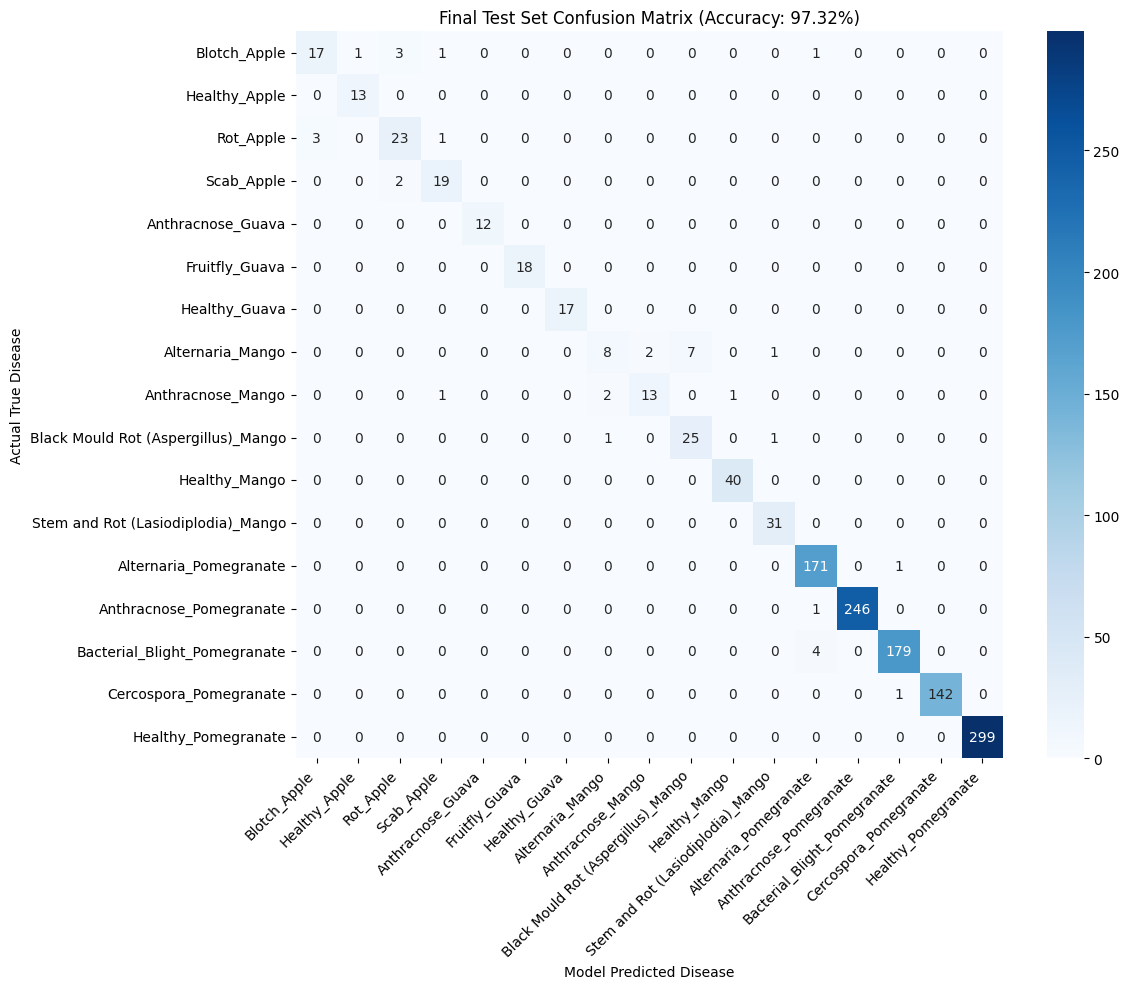

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

print("EVALUATING ON TEST SET")

model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        
        # Store for detailed metrics
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate overall metrics
final_test_acc = 100 * test_correct / test_total
final_test_loss = test_loss / test_total

print(f"Test Loss: {final_test_loss:.4f}")
print(f"Test Accuracy: {final_test_acc:.2f}%\n")

class_names = full_dataset.classes

print("DETAILED CLASSIFICATION REPORT")

# Need to check for recall on the minority classes
print(classification_report(all_labels, all_preds, target_names=class_names))


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, 
            yticklabels=class_names)
plt.ylabel('Actual True Disease')
plt.xlabel('Model Predicted Disease')
plt.title(f'Final Test Set Confusion Matrix (Accuracy: {final_test_acc:.2f}%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()